# **Mount my Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Check to see if we're running in Colab (versus local server)

In [ ]:
try:
  from google.colab import drive
  IN_COLAB=True
except:
  IN_COLAB=False

if IN_COLAB:
  print("We're running Colab")

We're running Colab


## Enabling and testing the GPU

First, you'll need to enable GPUs for the notebook:

- Navigate to Edit→Notebook Settings
- select GPU from the Hardware Accelerator drop-down

Next, we'll confirm that we can connect to the GPU with tensorflow:

In [ ]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


## Observe TensorFlow speedup on GPU relative to CPU

This example constructs a typical convolutional neural network layer over a
random image and manually places the resulting ops on either the CPU or the GPU
to compare execution speed.

In [ ]:
import tensorflow as tf
import timeit

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print(
      '\n\nThis error most likely means that this notebook is not '
      'configured to use a GPU.  Change this in Notebook Settings via the '
      'command palette (cmd/ctrl-shift-P) or the Edit menu.\n\n')
  raise SystemError('GPU device not found')

def cpu():
  with tf.device('/cpu:0'):
    random_image_cpu = tf.random.normal((100, 100, 100, 3))
    net_cpu = tf.keras.layers.Conv2D(32, 7)(random_image_cpu)
    return tf.math.reduce_sum(net_cpu)

def gpu():
  with tf.device('/device:GPU:0'):
    random_image_gpu = tf.random.normal((100, 100, 100, 3))
    net_gpu = tf.keras.layers.Conv2D(32, 7)(random_image_gpu)
    return tf.math.reduce_sum(net_gpu)

# We run each op once to warm up; see: https://stackoverflow.com/a/45067900
cpu()
gpu()

# Run the op several times.
print('Time (s) to convolve 32x7x7x3 filter over random 100x100x100x3 images '
      '(batch x height x width x channel). Sum of ten runs.')
print('CPU (s):')
cpu_time = timeit.timeit('cpu()', number=10, setup="from __main__ import cpu")
print(cpu_time)
print('GPU (s):')
gpu_time = timeit.timeit('gpu()', number=10, setup="from __main__ import gpu")
print(gpu_time)
print('GPU speedup over CPU: {}x'.format(int(cpu_time/gpu_time)))

Time (s) to convolve 32x7x7x3 filter over random 100x100x100x3 images (batch x height x width x channel). Sum of ten runs.
CPU (s):
1.0899948210000048
GPU (s):
0.08202038900003572
GPU speedup over CPU: 13x




---



# **Script Start**

In [ ]:
import numpy as np
import json
import os
import csv #[Hyosun]
import pandas as pd #[Hyosun]
import random       #[Hyosun]

# [Hyosun] confusion matrix
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
# [/Hyosun] confusion matrix

In [ ]:
cwd = os.getcwd()
print(cwd)

/content


In [ ]:
os.chdir('/content/drive/MyDrive/hssast/src/finetune')
print(os.getcwd())
cur_dir = os.getcwd()

/content/drive/MyDrive/hssast/src/finetune


In [ ]:
dataset_folder = '/Emotions'

In [ ]:
# dataset_folder = '/Isolated_urbansound'

In [ ]:
os.chdir(cur_dir+dataset_folder) #+'/exp/') #+ result_dir+'/')

In [ ]:
cur_dir = os.getcwd()
print(cur_dir)

/content/drive/MyDrive/hssast/src/finetune/Emotions


#**Emotions Spectrogram**

In [ ]:
# [Hyosun] this is a sample code of how to get a sample and patches of input spectrogram

import torch
import numpy as np

import dataloader #[Hyosun comment] 현재파일은 자체제작한 dataloader.py랑 연동되는 파일임(같은경로에 dataloader.py두기)
import matplotlib.pyplot as plt  #[Hyosun]added to show spectrogram


# set skip_norm as True only when you are computing the normalization stats
audio_conf = {'num_mel_bins': 128, 'target_length': 1024, 'freqm': 24, 'timem': 192, 'mixup': 0.5, 'skip_norm': True, 'mode': 'train', 'dataset': 'event'}

train_loader = torch.utils.data.DataLoader(
    # [Hyosun] edited as the function name changed by SSAST team since AST
    # dataloader.AudiosetDataset('./data/datafiles/tau_train_data_1.json', label_csv='./data/tau_class_labels_indices.csv',
    dataloader.AudioDataset('/content/drive/MyDrive/hssast/src/finetune/Emotions/data/datafiles/emotions_train_data_1.json',\
     label_csv='/content/drive/MyDrive/hssast/src/finetune/Emotions/data/emotions_class_labels_indices.csv',
                                audio_conf=audio_conf), batch_size=1000, shuffle=False, num_workers=8, pin_memory=True)
                                                        #[Hyosun] batch size(This is not a real batch_size, we assign the real one at run.py: train_loader),
                                                        ##        doesn't matter with the mean,std,length
    # [/Hyosun] edited as the function name changed by SSAST team since AST


---------------the train dataloader---------------
now using following mask: 24 freq, 192 time
now using mix-up with rate 0.500000
now process event
now skip normalization (use it ONLY when you are computing the normalization stats).
number of classes is 7


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be7f6a58040>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1478, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1461, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


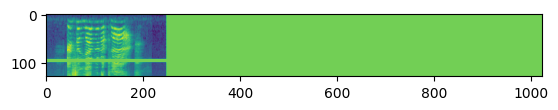

In [ ]:
for i, (audio_input, labels) in enumerate(train_loader):
    if i == 1:
      plt.imshow(np.transpose(audio_input[0,:,:]))
      break

# mean=[]
# std=[]
# for i, (audio_input, labels) in enumerate(train_loader):
#     cur_mean = torch.mean(audio_input)
#     cur_std = torch.std(audio_input)
#     mean.append(cur_mean)
#     std.append(cur_std)
#     print(cur_mean, cur_std)
# print(np.mean(mean), np.mean(std))

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be7f6a58040>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1478, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1461, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7be7f6a58040>
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1478, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py", line 1461, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

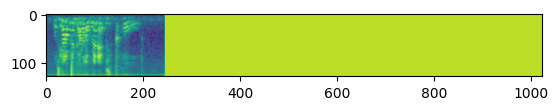

In [ ]:
for i, (audio_input, labels) in enumerate(train_loader):
    if i == 0:
      plt.imshow(np.transpose(audio_input[0,:,:]))
      break

# mean=[]
# std=[]
# for i, (audio_input, labels) in enumerate(train_loader):
#     cur_mean = torch.mean(audio_input)
#     cur_std = torch.std(audio_input)
#     mean.append(cur_mean)
#     std.append(cur_std)
#     print(cur_mean, cur_std)
# print(np.mean(mean), np.mean(std))

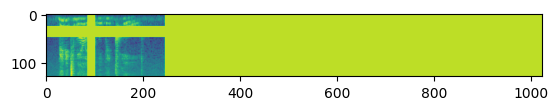

In [ ]:
for i, (audio_input, labels) in enumerate(train_loader):
    if i == 0:
      plt.imshow(np.transpose(audio_input[0,:,:]))
      plt.savefig('emotion_spectrogram'+str(i)+'.png',dpi=300)
      break

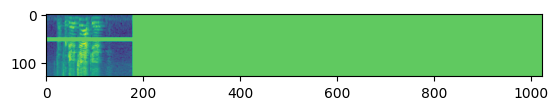

In [ ]:
for i, (audio_input, labels) in enumerate(train_loader):
    if i == 3:
      plt.imshow(np.transpose(audio_input[0,:,:]))
      break

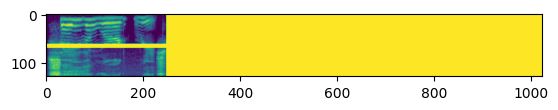

In [ ]:
for i, (audio_input, labels) in enumerate(train_loader):
    if i == 4:
      plt.imshow(np.transpose(audio_input[0,:,:]))
      break

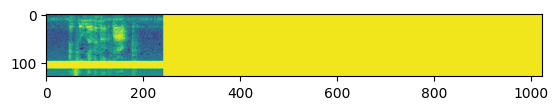

In [ ]:
for i, (audio_input, labels) in enumerate(train_loader):
    if i == 5:
      plt.imshow(np.transpose(audio_input[0,:,:]))
      break

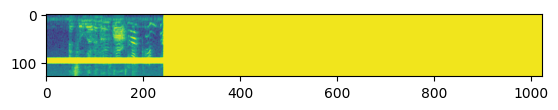

In [ ]:
for i, (audio_input, labels) in enumerate(train_loader):
    if i == 5:
      plt.imshow(np.transpose(audio_input[0,:,:]))
      break

# mean=[]
# std=[]
# for i, (audio_input, labels) in enumerate(train_loader):
#     cur_mean = torch.mean(audio_input)
#     cur_std = torch.std(audio_input)
#     mean.append(cur_mean)
#     std.append(cur_std)
#     print(cur_mean, cur_std)
# print(np.mean(mean), np.mean(std))

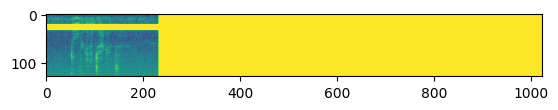

In [ ]:
for i, (audio_input, labels) in enumerate(train_loader):
    if i == 7:
      plt.imshow(np.transpose(audio_input[0,:,:]))
      break

# mean=[]
# std=[]
# for i, (audio_input, labels) in enumerate(train_loader):
#     cur_mean = torch.mean(audio_input)
#     cur_std = torch.std(audio_input)
#     mean.append(cur_mean)
#     std.append(cur_std)
#     print(cur_mean, cur_std)
# print(np.mean(mean), np.mean(std))

# **IurbanEvent Spectrogram example**

In [ ]:
# [Hyosun] this is a sample code of how to get a sample and patches of input spectrogram

import torch
import numpy as np

import dataloader #[Hyosun comment] 현재파일은 자체제작한 dataloader.py랑 연동되는 파일임(같은경로에 dataloader.py두기)
import matplotlib.pyplot as plt  #[Hyosun]added to show spectrogram


# set skip_norm as True only when you are computing the normalization stats
audio_conf = {'num_mel_bins': 128, 'target_length': 1024, 'freqm': 24, 'timem': 192, 'mixup': 0.5, 'skip_norm': True, 'mode': 'train', 'dataset': 'event'}

train_loader = torch.utils.data.DataLoader(
    # [Hyosun] edited as the function name changed by SSAST team since AST
    # dataloader.AudiosetDataset('./data/datafiles/tau_train_data_1.json', label_csv='./data/tau_class_labels_indices.csv',
    dataloader.AudioDataset('/content/drive/MyDrive/hssast/src/finetune/Isolated_urbansound/data/datafiles/event_04s_train_data_1.json',\
     label_csv='/content/drive/MyDrive/hssast/src/finetune/Isolated_urbansound/data/event_04s_class_labels_indices.csv',
                                audio_conf=audio_conf), batch_size=1000, shuffle=False, num_workers=8, pin_memory=True)
                                                        #[Hyosun] batch size(This is not a real batch_size, we assign the real one at run.py: train_loader),
                                                        ##        doesn't matter with the mean,std,length
    # [/Hyosun] edited as the function name changed by SSAST team since AST


In [ ]:
for i, (audio_input, labels) in enumerate(train_loader):
    if i ==1:
      plt.imshow(np.transpose(audio_input[i,:,:]))
      break

# mean=[]
# std=[]
# for i, (audio_input, labels) in enumerate(train_loader):
#     cur_mean = torch.mean(audio_input)
#     cur_std = torch.std(audio_input)
#     mean.append(cur_mean)
#     std.append(cur_std)
#     print(cur_mean, cur_std)
# print(np.mean(mean), np.mean(std))